# Kaggriculture, Visualized: A Beginner's Guide to Every Mechanic (and What Every Crop Pays)

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin)*

New to [Kaggriculture](https://www.kaggle.com/competitions/kaggriculture)? This is the fast way in.
Starter notebooks hand you a bot and a wall of code — this one *shows* you the farm. In a few
minutes you will see every mechanic drawn out (the board, the crop schedules, the market curves that
punish a glut, the town that quadruples its appetite by day 20), and you will leave with a small
working bot you can fork.

In [1]:
# Works on Kaggle with Internet on (first run upgrades kaggle-environments if the image is stale).
import contextlib, glob, io, os, subprocess, sys
from importlib import metadata

def _version_ok():
    try:  # checked without importing, so an upgrade below actually takes effect
        return tuple(int(x) for x in
                     metadata.version("kaggle-environments").split(".")[:3]) >= (1, 32, 3)
    except Exception:
        return False

if not _version_ok():
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--progress-bar", "off",
                        "-U", "kaggle-environments>=1.32.3"], check=True, capture_output=True)
    except Exception as e:
        raise RuntimeError("This guide needs kaggle-environments >= 1.32.3 — "
                           "turn Internet ON in the notebook settings and rerun.") from e

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import logging
logging.disable(logging.INFO)  # other bundled envs log noise on import; mute it
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    import kaggle_environments
    from kaggle_environments import make
logging.disable(logging.NOTSET)
from kaggle_environments.envs.kaggriculture.kaggriculture import (
    CROPS, ANIMALS, MARKET_PARAMS, MARKET_I0, SHOPS, LAND_ORDER, LAND_PRICES,
    PRODUCTS, TOWN_CENTER_DEMAND_SCHEDULE, market_price,
)

plt.rcParams.update({
    "figure.dpi": 90, "savefig.dpi": 90, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
})

# Colorblind-safe palette (validated: CVD ΔE and lightness checks pass)
CROP_C = {"WHEAT": "#C99700", "CARROT": "#B84A00", "TOMATO": "#9E2B72",
          "STRAWBERRY": "#DB6FA9", "MELON": "#00795F"}
PROD_C = {**CROP_C, "EGG": "#56A8D8", "MILK": "#0059A1", "WOOL": "#A8641A",
          "FERTILIZER": "#6B4F9E"}
P0, P1 = "#0072B2", "#D55E00"          # our bot / opponent
# Surface tones lifted from the visualizer that ships with the environment, so the
# farms here look like the farms in the official replay player.
SOIL, TILLED, WILD = "#efe7ce", "#e8d2a6", "#c2caa4"
WOOD, WOOD_DARK, INK = "#8b6f44", "#3a2412", "#3c3b37"
BASE = {p: MARKET_PARAMS[p]["base"] for p in PRODUCTS}

def one_shot_units(crop):
    # Watering during the bonus window adds +1/day (+2 if fertilized), capped at max_yield.
    c = CROPS[crop]
    window = range((c["max_yield_day"] + 1) // 2, c["max_yield_day"] + 1)
    return min(c["max_yield"], 1 + len(list(window)))

def one_shot_days(crop):
    # The tile is free once the plant is BOTH harvestable and done growing. Watering adds +1/day
    # from a base of 1, starting at the window, so the cap can bind before max_yield_day: a melon
    # is finished on day 10, not 12. Wheat and carrot never reach their cap, so nothing changes.
    c = CROPS[crop]
    cap_day = (c["max_yield_day"] + 1) // 2 + c["max_yield"] - 2
    return max(c["first_yield_day"], min(cap_day, c["max_yield_day"]))

def ongoing_days(crop):
    # The days a fruit can be picked up. _daily_refresh_plants runs with next_day = day + 1, so the
    # unit that forms overnight is in your hands on the morning of first_yield_day, then every
    # `interval` days after that, max_yield times.
    c = CROPS[crop]
    return [c["first_yield_day"] + k * c["interval"] for k in range(c["max_yield"])]

def crop_econ():
    # Profit per tile-day at base prices, daily watering, no fertilizer.
    rows = []
    for crop, c in CROPS.items():
        if c["ongoing"]:
            days = ongoing_days(crop)
            units, occupied = c["max_yield"], days[-1]       # DIG frees the tile the same day
        else:
            units, occupied = one_shot_units(crop), one_shot_days(crop)
        revenue = units * BASE[crop]
        profit = revenue - c["seed"]
        rows.append({"crop": crop, "seed $": c["seed"], "tile-days": occupied, "units": units,
                     "base price": BASE[crop], "revenue $": revenue, "profit $": profit,
                     "profit / tile-day": round(profit / occupied, 1)})
    return pd.DataFrame(rows).sort_values("profit / tile-day", ascending=False).reset_index(drop=True)

def draw_farm(ax, farm, title=""):
    # One farm, drawn in the environment's own colours; tiles[y][x] with row 0 on top.
    from matplotlib.patches import FancyBboxPatch

    def tile(x, y, fc, ec="white", lw=1.0, alpha=1.0):
        ax.add_patch(FancyBboxPatch((x + .07, n - 1 - y + .07), .86, .86,
                                    boxstyle="round,pad=0,rounding_size=0.16",
                                    fc=fc, ec=ec, lw=lw, alpha=alpha))

    n = len(farm["tiles"])
    ax.add_patch(plt.Rectangle((-.15, -.15), n + .3, n + .3, fc=SOIL, ec="none", zorder=0))
    for y in range(n):
        for x in range(n):
            t = farm["tiles"][y][x]
            if t == "LOCKED":                       # wild land, not bought yet
                tile(x, y, WILD, ec="#b3bd94", lw=.8)
                continue
            tile(x, y, TILLED, ec=SOIL, lw=.8)      # ground you own and work
            if not isinstance(t, dict):
                continue
            k = t.get("kind")
            if k == "PLANT":
                ripe = t.get("yield_units", 0) > 0
                tile(x, y, CROP_C[t["crop"]], alpha=1.0 if ripe else .45)
                if ripe:                            # a dot means there is something to harvest
                    ax.plot(x + .5, n - 1 - y + .5, "o", ms=3.4, mfc="white", mec="none", zorder=6)
            elif k == "WEED":
                tile(x, y, "#6E7351", alpha=.55)
            elif "animal" in t:
                tile(x, y, PROD_C[ANIMALS[t["animal"]]["product"]])
            elif k in ("COOP", "PASTURE"):
                tile(x, y, WOOD, alpha=.5)
    ax.plot([n/2, n/2], [0, n], color=WOOD_DARK, lw=2.4, alpha=.85, zorder=4)
    ax.plot([0, n], [n/2, n/2], color=WOOD_DARK, lw=2.4, alpha=.85, zorder=4)
    ax.add_patch(FancyBboxPatch((n/2 - .62, n/2 - .62), 1.24, 1.24,
                                boxstyle="round,pad=0,rounding_size=0.18",
                                fc=WOOD_DARK, ec=SOIL, lw=1.6, zorder=5))
    ax.text(n/2, n/2, "shed", ha="center", va="center", fontsize=6.5, color=SOIL, zorder=6)
    fx, fy = farm["farmer"]
    ax.plot(fx + .5, n - 1 - fy + .5, "o", ms=8.5, mfc=P0, mec="white", mew=1.4, zorder=7)
    for hx, hy in farm.get("hands", []):
        ax.plot(hx + .5, n - 1 - hy + .5, "o", ms=5.5, mfc=P0, mec="white", mew=1.1, zorder=7)
    ax.set_xlim(-.2, n + .2); ax.set_ylim(-.2, n + .2)
    ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=11, color=INK)


def day_frames(steps):
    # Index of the last turn of every in-game day, so one frame is one day.
    days = sorted({s[0]["observation"]["day"] for s in steps})
    return days, [max(i for i, s in enumerate(steps) if s[0]["observation"]["day"] == d)
                  for d in days]


def season_gif(steps, out="season.gif", fps=5):
    # One frame per in-game day: the farm on the left, the money race on the right.
    from matplotlib.animation import FuncAnimation, PillowWriter
    days, last = day_frames(steps)
    money = [[s[0]["observation"]["farms"][p]["money"] for s in steps] for p in (0, 1)]
    top = max(max(money[0]), max(money[1])) * 1.08

    fig, (axF, axM) = plt.subplots(1, 2, figsize=(7.8, 3.6),
                                   gridspec_kw={"width_ratios": [1.05, 1.05]})
    def frame(i):
        k = last[i]
        axF.clear(); axM.clear()
        draw_farm(axF, steps[k][0]["observation"]["farms"][0])
        axF.set_title(f"Day {days[i]} of {days[-1]}", fontsize=11.5, color=INK, weight="bold")
        axM.plot(money[0][:k + 1], color=P0, lw=2.4, label="Carrot Crew")
        axM.plot(money[1][:k + 1], color=P1, lw=2.4, label="built-in starter")
        axM.set_xlim(0, len(steps)); axM.set_ylim(0, top)
        axM.set_title("Coins in the bank", fontsize=11.5, color=INK, weight="bold")
        axM.set_xlabel("turn", fontsize=9)
        axM.legend(fontsize=8.5, frameon=False, loc="upper left")

    FuncAnimation(fig, frame, frames=len(last)).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)
    return out


import glob, os

def data_file(name):
    # The attached dataset on Kaggle, a differently-named copy of it, or a local checkout.
    for d in ["/kaggle/input/kaggriculture-episodes", *glob.glob("/kaggle/input/*"),
              "episodes", "../episodes"]:
        if os.path.exists(f"{d}/{name}"):
            return f"{d}/{name}"
    raise FileNotFoundError(
        f"{name} not found. Attach the dataset: Add Input -> Datasets -> search "
        "'kaggriculture-episodes' (georgymamarin/kaggriculture-episodes)."
    )

def load_table(stem):
    for ext, reader in ((".parquet", pd.read_parquet), (".csv", pd.read_csv)):
        try:
            return reader(data_file(f"{stem}{ext}"))
        except FileNotFoundError:
            continue
    raise FileNotFoundError(f"no {stem}.csv or {stem}.parquet in the attached dataset")


def hero_gif(out="hero.gif", fps=5):
    # A real ladder season: the farm fills up while the town's appetite lifts prices.
    import json
    from matplotlib.animation import FuncAnimation, PillowWriter

    ladder = load_table("episodes")
    ladder = ladder[ladder["type"] == "EPISODE_TYPE_PUBLIC"].copy()
    ladder["top"] = ladder[["bank_0", "bank_1"]].max(axis=1)
    row = ladder.sort_values("top", ascending=False).iloc[0]
    seat = 0 if row.bank_0 >= row.bank_1 else 1
    steps = json.loads(pd.read_parquet(
        data_file("replays.parquet"),
        filters=[("episode_id", "==", int(row.episode_id))]).iloc[0].replay_json)["steps"]

    days, last = day_frames(steps)
    watch = ["MILK", "STRAWBERRY", "MELON", "WHEAT"]
    series = {p: [steps[k][0]["observation"]["market"]["prices"][p] for k in last] for p in watch}
    ceiling = max(max(v) for v in series.values()) * 1.12

    fig = plt.figure(figsize=(8.0, 3.7))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.22], left=.02, right=.9, top=.8, bottom=.14,
                          wspace=.12)
    axF, axP = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    def frame(i):
        axF.clear(); axP.clear()
        farm = steps[last[i]][0]["observation"]["farms"][seat]
        draw_farm(axF, farm)
        axF.set_title(f"Day {days[i]}   ${farm['money']:,.0f}", fontsize=12, color=INK, weight="bold")
        for mark, mult in ((10, "x2"), (20, "x4")):
            if days[i] >= mark:                       # the town's appetite steps up here
                axP.axvline(mark, color="#b9ae95", lw=1.2, ls=":")
                axP.text(mark + .3, ceiling * .04, f"town {mult}", fontsize=8, color="#8A7F6B")
        spread = sorted(watch, key=lambda p: -series[p][i])
        placed = None
        for prod in spread:
            axP.plot(days[:i + 1], series[prod][:i + 1], lw=2.6, color=PROD_C[prod])
            y = series[prod][i]
            if placed is not None and y > placed - ceiling * .07:
                y = placed - ceiling * .07                          # stack labels, never overlap
            placed = y
            axP.text(days[i] + .6, y, f"{prod.title()} ${series[prod][i]}",
                     fontsize=8.5, color=PROD_C[prod], va="center", weight="bold")
        axP.set_xlim(0, days[-1] * 1.34); axP.set_ylim(0, ceiling)
        axP.set_title("What the town pays", fontsize=12, color=INK, weight="bold")
        axP.set_xlabel("day", fontsize=9)
        axP.tick_params(labelsize=8.5)

    FuncAnimation(fig, frame, frames=len(days)).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)

    stock = [steps[k][0]["observation"]["market"]["inventory"]["MELON"] for k in last]
    jump = max(range(1, len(stock)), key=lambda i: stock[i] - stock[i - 1])
    print(f"Biggest melon dump in this game: {stock[jump] - stock[jump - 1]} sold into the market "
          f"on day {days[jump]}, price ${series['MELON'][jump - 1]} -> ${series['MELON'][jump]}.")
    return out


def dump_gif(item="MELON", n=200, out="dump.gif", fps=10):
    # Sell one unit at a time into an untouched market and watch the price walk down.
    from matplotlib.animation import FuncAnimation, PillowWriter
    prices = [market_price(item, MARKET_I0 + k) for k in range(n)]
    earned = np.cumsum(prices)
    dream = np.arange(1, n + 1) * prices[0]          # if the price never moved
    shed = 100                                       # shedCapacity: one dump can be this big
    step = 5

    fig, (axP, axR) = plt.subplots(1, 2, figsize=(8.0, 3.4))
    def frame(f):
        k = min((f + 1) * step, n) - 1
        axP.clear(); axR.clear()
        axP.plot(range(n), prices, lw=2.6, color=CROP_C[item], alpha=.3)
        axP.plot(range(k + 1), prices[:k + 1], lw=3, color=CROP_C[item])
        axP.plot(k, prices[k], "o", ms=9, color=CROP_C[item], mec="white", mew=1.6)
        axP.text(.97, .92, f"unit {k + 1}: ${prices[k]}", transform=axP.transAxes, ha="right",
                 fontsize=12, weight="bold", color=CROP_C[item])
        axP.set_title(f"{item.title()} price while you sell", fontsize=11.5, color=INK)
        axP.set_xlabel("units sold in one go"); axP.set_ylabel("price $")
        axP.axvline(shed, color="#8A7F6B", lw=1.4, ls="--")
        axP.text(shed - 3, prices[0] * .12, "one shed ", fontsize=8.5, color="#8A7F6B", ha="right")
        axP.set_xlim(0, n); axP.set_ylim(0, prices[0] * 1.1)

        axR.plot(range(k + 1), dream[:k + 1], lw=2.4, ls="--", color="#8A7F6B")
        axR.plot(range(k + 1), earned[:k + 1], lw=3, color=CROP_C[item])
        axR.text(.04, .93, f"kept ${earned[k]:,.0f}", transform=axR.transAxes, fontsize=12,
                 weight="bold", color=CROP_C[item], va="top")
        axR.text(.04, .78, f"hoped ${dream[k]:,.0f}", transform=axR.transAxes, fontsize=11,
                 color="#8A7F6B", va="top")
        axR.set_title("What the sale actually pays", fontsize=11.5, color=INK)
        axR.set_xlabel("units sold in one go"); axR.set_ylabel("coins so far")
        axR.axvline(shed, color="#8A7F6B", lw=1.4, ls="--")
        axR.set_xlim(0, n); axR.set_ylim(0, dream[-1] * 1.05)
        plt.tight_layout()

    FuncAnimation(fig, frame, frames=n // step).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)
    return out, {"shed": (int(earned[shed - 1]), int(dream[shed - 1])),
                 "all": (int(earned[-1]), int(dream[-1])), "last": prices[-1]}


def versus_gif(my_steps, out="versus.gif", fps=5):
    # Our farm next to the biggest ladder farm in the dataset, day for day.
    import json
    from matplotlib.animation import FuncAnimation, PillowWriter

    ladder = load_table("episodes")
    ladder = ladder[ladder["type"] == "EPISODE_TYPE_PUBLIC"].copy()
    ladder["top"] = ladder[["bank_0", "bank_1"]].max(axis=1)
    row = ladder.sort_values("top", ascending=False).iloc[0]
    seat = 0 if row.bank_0 >= row.bank_1 else 1
    replay = pd.read_parquet(data_file("replays.parquet"),
                             filters=[("episode_id", "==", int(row.episode_id))])
    their_steps = json.loads(replay.iloc[0].replay_json)["steps"]

    my_days, my_last = day_frames(my_steps)
    their_days, their_last = day_frames(their_steps)
    n = min(len(my_days), len(their_days))

    fig = plt.figure(figsize=(8.0, 4.7))
    gs = fig.add_gridspec(2, 2, height_ratios=[3.1, 1], hspace=.3, wspace=.06,
                          left=.09, right=.97, top=.88, bottom=.14)
    axL, axR, axB = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])

    def frame(i):
        axL.clear(); axR.clear(); axB.clear()
        mine = my_steps[my_last[i]][0]["observation"]["farms"][0]
        theirs = their_steps[their_last[i]][0]["observation"]["farms"][seat]
        draw_farm(axL, mine); draw_farm(axR, theirs)
        axL.set_title(f"Carrot Crew   ${mine['money']:,.0f}", fontsize=11, color=P0, weight="bold")
        axR.set_title(f"a ladder leader   ${theirs['money']:,.0f}", fontsize=11, color=INK,
                      weight="bold")
        scale = max(theirs["money"], mine["money"], 1) * 1.35
        axB.barh([1, 0], [mine["money"], theirs["money"]], color=[P0, "#8A7F6B"], height=.55)
        axB.text(scale * .99, .5, f"×{theirs['money'] / max(mine['money'], 1):.0f}",
                 ha="right", va="center", fontsize=13, weight="bold", color=INK)
        axB.set_yticks([1, 0], ["mine", "theirs"], fontsize=9)
        axB.set_xlim(0, scale); axB.set_xlabel("coins in the bank", fontsize=9)
        for sp in ("top", "right", "left"):
            axB.spines[sp].set_visible(False)
        fig.suptitle(f"Same rules, same day {my_days[i]} of {my_days[n - 1]}",
                     fontsize=12.5, color=INK, weight="bold", y=.97)

    FuncAnimation(fig, frame, frames=n).save(out, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)

    final = their_steps[-1][0]["observation"]["farms"][seat]
    beasts = sum(1 for r in final["tiles"] for t in r if isinstance(t, dict) and "animal" in t)
    print(f"Their farm ended on {len(final['unlocked_quadrants'])} of 4 quadrants "
          f"with {beasts} animals; ours on 1 quadrant with none.")
    return out


def show_gif(path):
    import base64
    from IPython.display import HTML, display
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    display(HTML(f'<img src="data:image/gif;base64,{b64}" alt="a full season" '
                 'style="width:100%;max-width:760px;height:auto;border-radius:10px;"/>'))


# ---- hero: a real season, animated, before any prose ----
try:
    show_gif(hero_gif(out="hero.gif"))
except FileNotFoundError as e:      # the guide still works without the ladder dataset
    print(e)

print(f"Engine loaded (kaggle-environments {kaggle_environments.__version__}).",
      "Crops:", ", ".join(CROPS), "| Products:", len(PRODUCTS))

no episodes.csv or episodes.parquet in the attached dataset
Engine loaded (kaggle-environments 1.32.4). Crops: WHEAT, CARROT, TOMATO, STRAWBERRY, MELON | Products: 9


That is the biggest ladder game in the dataset, thirty days in six seconds. The farm fills up, and
the prices the town pays drift upward the whole season, because the town eats every day and two
farms cannot keep its shelves full; the dotted lines mark where its appetite doubles. Then watch
melon dip in a single day. That is the same farm emptying a shed into the market at once, and the
line under the animation names the day. Prices move both ways here, and section 9 measures how far.

One promise up front: **every number on every chart is read from a real source, never typed from
memory.** Sections 1 to 14 import their constants and the price function straight from the official
`kaggle_environments` package, and each chart is generated by the cell right above it. The animation
at the top and the charts in section 15 say so out loud: those come from real ladder games in my
[Kaggriculture Episodes](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes)
dataset, attached to this notebook. Where a fact comes from
the competition rules instead (submission limits, timeouts), I flag it too. If this saves you an
evening of reading source code, it has done its job.

## What you will learn (jump anywhere)

1. [The farm: four quadrants, one shed](#s1) — where you start and what the other three quadrants cost
2. [The clock: 24 turns a day](#s2) — what happens at hour 23 catches everyone out
3. [Crops: five plants, five schedules](#s3) — growth timelines, side by side
4. [What a tile actually pays](#s4) — profit per tile-day at base prices
5. [Water it or lose it](#s5) — weeds, decay, and what fertilizer really does
6. [Animals: wheat-powered factories](#s6) — payback day for goose, cow, sheep
7. [Hired hands: the Fibonacci labor market](#s7) — why labor is almost free
8. [Land: the cheapest scaling in the game](#s8) — when a quadrant pays for itself
9. [The market: every sale moves the price](#s9) — the curves, product by product
10. [The town: demand that quadruples](#s10) — free price support, on a schedule
11. [How you actually play](#s11) — observation and action, decoded
12. [A starter bot you can fork](#s12) — six carrot tiles, fully commented
13. [Watch a full game](#s13) — snapshots and the money curve
14. [Measure it before you optimize it](#s14) — replay and seat checks, then a same-seed comparison
15. [From the starter bot to a real strategy](#s15) — the ladder as a yardstick, then the fix list
16. [Cheat sheet](#s16) — the whole game in two tables
17. [Submit your agent](#s17) — three ways, and the 1-second rule
18. [Further reading & credits](#s18)

<a id="s1"></a>
## 1. The farm: four quadrants, one shed

Each player runs their own 10×10 farm — you never walk on your opponent's land; you only share the
**market**. Your farm is four 5×5 quadrants. You start with **\$3,000**, the **NW quadrant**, one
farmer, and a shed in the center. The other three quadrants are bought with `BUY_LAND` in a fixed
order — NE, then SW, then SE — at \$1,000 / \$2,000 / \$4,000. The shed is where harvested goods must
end up before you can sell them. The four tiles touching its corners are "shed-adjacent" — until
you buy land, only the NW one is on your side of the fence, and your farmer spawns there every
morning.

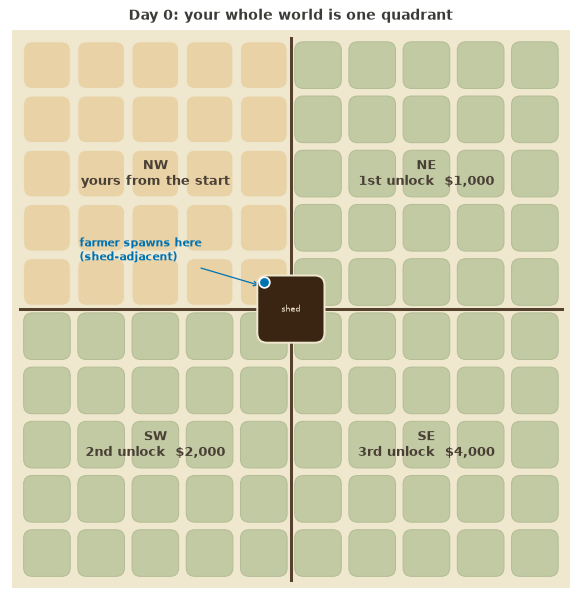

In [3]:
env = make("kaggriculture", configuration={"seed": 42})
env.reset()
farm0 = env.state[0].observation["farms"][0]

fig, ax = plt.subplots(figsize=(6.8, 6.8))
draw_farm(ax, farm0, "Day 0: your whole world is one quadrant")
labels = {"NW": (2.5, 7.5, "NW\nyours from the start"),
          "NE": (7.5, 7.5, f"NE\n1st unlock  ${LAND_PRICES[0]:,}"),
          "SW": (2.5, 2.5, f"SW\n2nd unlock  ${LAND_PRICES[1]:,}"),
          "SE": (7.5, 2.5, f"SE\n3rd unlock  ${LAND_PRICES[2]:,}")}
for q, (x, y, txt) in labels.items():
    ax.text(x, y, txt, ha="center", va="center", fontsize=10.5, color="#4A3F35", weight="bold")
ax.annotate("farmer spawns here\n(shed-adjacent)", xy=(4.55, 5.4), xytext=(1.1, 5.9),
            fontsize=9, color=P0, weight="bold",
            arrowprops=dict(arrowstyle="->", color=P0, shrinkA=4, shrinkB=6))
plt.tight_layout(); plt.show()

The unlock order is fixed in the engine (`LAND_ORDER = ["NE", "SW", "SE"]`), so the only land
decision you actually make is **when** to buy. We will price that decision in section 8.

<a id="s2"></a>
## 2. The clock: 24 turns a day, and the night that resets everything

A game is **720 turns = 30 days × 24 turns**. Every turn, each of your units (farmer + hired hands)
performs exactly one action, and you may also place up to **10 market orders**. Then the town takes
its bite: every unlocked shop consumes its products every 4 turns; the town center consumes every
product except fertilizer every 12 turns. At the end of each day comes the reset that surprises
everyone.

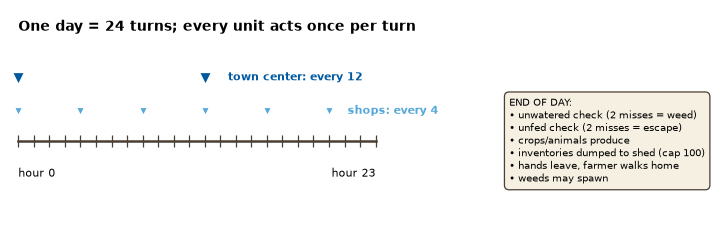

In [4]:
fig, ax = plt.subplots(figsize=(8.2, 2.9))
ax.set_xlim(-.6, 40); ax.set_ylim(-.8, 3.4); ax.axis("off"); ax.grid(False)
ax.plot([0, 23], [1, 1], color="#4A3F35", lw=2, zorder=1)
for h in range(24):
    ax.plot(h, 1, "|", ms=10, color="#4A3F35")
shop_hours = [h for h in range(24) if h % 4 == 0]
center_hours = [h for h in range(24) if h % 12 == 0]
ax.plot(shop_hours, [1.55] * len(shop_hours), "v", ms=7, color=PROD_C["EGG"], mec="white")
ax.plot(center_hours, [2.15] * len(center_hours), "v", ms=9, color=PROD_C["MILK"], mec="white")
ax.text(21.2, 1.55, "shops: every 4", fontsize=8.5, va="center", color=PROD_C["EGG"], weight="bold")
ax.text(13.5, 2.15, "town center: every 12", fontsize=8.5, va="center", color=PROD_C["MILK"], weight="bold")
ax.text(0, .35, "hour 0", fontsize=9); ax.text(23, .35, "hour 23", fontsize=9, ha="right")
ax.text(0, 3.0, "One day = 24 turns; every unit acts once per turn", fontsize=11, weight="bold")
ax.text(31.6, 1.0, "END OF DAY:\n• unwatered check (2 misses = weed)\n• unfed check (2 misses = escape)\n• crops/animals produce\n• inventories dumped to shed (cap 100)\n• hands leave, farmer walks home\n• weeds may spawn",
        fontsize=8.4, va="center", ha="left",
        bbox=dict(boxstyle="round,pad=0.45", fc="#F6F0E2", ec="#4A3F35"))
plt.tight_layout(); plt.show()

Three consequences worth engraving: **(1)** anything a unit is carrying is auto-dropped into the
shed at night, but the shed holds only **100 items — overflow is destroyed**; **(2)** hired hands
exist for one day only; **(3)** your farmer teleports back to the shed every morning, so distant
tiles cost you commute turns every single day.

<a id="s3"></a>
## 3. Crops: five plants, five schedules

Two families. **One-shot crops** (wheat, carrot, melon) grow once and are gone when harvested.
**Ongoing crops** (tomato, strawberry) keep producing on a fixed interval until they hit their
lifetime cap. Both families need watering, and the punishment schedule for skipping it is in
section 5. Here is every growth schedule, computed from the engine's `CROPS` table.

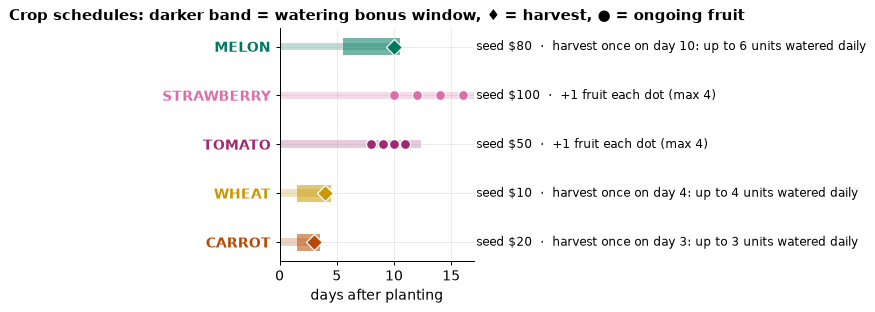

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 3.6))
order = ["CARROT", "WHEAT", "TOMATO", "STRAWBERRY", "MELON"]
for i, crop in enumerate(order):
    c, col = CROPS[crop], CROP_C[crop]
    if c["ongoing"]:
        days = ongoing_days(crop)
        ax.barh(i, days[-1] + 1.4, left=0, height=.16, color=col, alpha=.25)
        ax.plot(days, [i] * len(days), "o", ms=8, color=col, mec="white")
        note = f"+1 fruit each dot (max {c['max_yield']})"
    else:
        w0, done = (c["max_yield_day"] + 1) // 2, one_shot_days(crop)
        ax.barh(i, done, left=0, height=.16, color=col, alpha=.25)
        ax.barh(i, done - w0 + 1, left=w0 - .5, height=.34, color=col, alpha=.55)
        ax.plot(done, i, "D", ms=9, color=col, mec="white")
        note = f"harvest once on day {done}: up to {one_shot_units(crop)} units watered daily"
    ax.text(17.2, i, f"seed ${c['seed']}  ·  {note}", fontsize=9.5, va="center")
ax.set_yticks(range(len(order)), order)
for lbl in ax.get_yticklabels():
    lbl.set_color(CROP_C[lbl.get_text()]); lbl.set_weight("bold")
ax.set_xlim(0, 17); ax.set_xlabel("days after planting")
ax.set_title("Crop schedules: darker band = watering bonus window, ♦ = harvest, ● = ongoing fruit")
plt.tight_layout(); plt.show()

<a id="s4"></a>
## 4. What a tile actually pays

Seed cost, days of tile occupancy, units produced, revenue — all of it is in the engine's tables,
and it boils down to one number that matters for planning: **profit per tile-day**, at base
prices, assuming you water every day and skip fertilizer.

One count below will not match the engine's own table, so here it is up front. `max_yield_day` for
melon says 12, but a melon watered every day is already at its 6-unit cap on day 10, and harvesting
frees the tile the same day. I charge it 10 tile-days, because that is when you can plant the next
thing. Wheat and carrot never reach their cap, so nothing moves for them. romanrozen posted the
melon timing in the forum before I looked; the day count here is my own run of the engine.

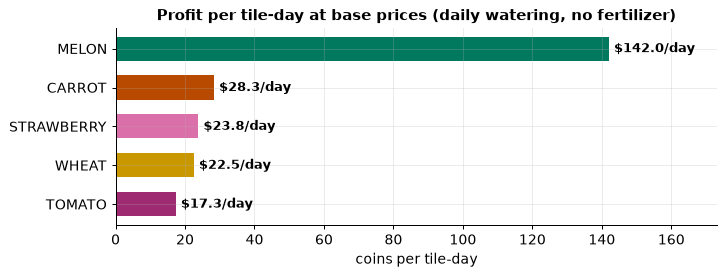

crop,seed $,tile-days,units,base price,revenue $,profit $,profit / tile-day
MELON,80,10,6,250,1500,1420,142.0
CARROT,20,3,3,35,105,85,28.3
STRAWBERRY,100,16,4,120,480,380,23.8
WHEAT,10,4,4,25,100,90,22.5
TOMATO,50,11,4,60,240,190,17.3


In [6]:
econ = crop_econ()

fig, ax = plt.subplots(figsize=(8.2, 3.2))
bars = ax.barh(econ["crop"][::-1], econ["profit / tile-day"][::-1],
               color=[CROP_C[c] for c in econ["crop"][::-1]], height=.62)
for b, v in zip(bars, econ["profit / tile-day"][::-1]):
    ax.text(b.get_width() + 1.5, b.get_y() + b.get_height() / 2, f"${v}/day", va="center",
            fontsize=10, weight="bold")
ax.set_xlim(0, econ["profit / tile-day"].max() * 1.22)
ax.set_title("Profit per tile-day at base prices (daily watering, no fertilizer)")
ax.set_xlabel("coins per tile-day")
plt.tight_layout(); plt.show()
econ.style.hide(axis="index").format(precision=1).set_properties(**{"font-size": "13px"}) \
    .set_table_styles([{"selector": "th", "props": [("font-size", "13px")]}])

On paper melon crushes everything, by a multiple you can read off the table above. Hold that
thought: section 9
shows what the market does to the *fourth* player who reaches the same conclusion. The quiet
takeaway is the opposite one: the humble carrot turns over in 3 days, which makes it the best
cash-flow engine of the early game, and wheat's real job is **animal feed** (section 6).

<a id="s5"></a>
## 5. Water it or lose it

The watering rules are strict, and one of them is genuinely sneaky:

<div style="background:#FDF3E3;border-left:4px solid #B84A00;padding:10px 14px;border-radius:4px">
<b>The planting day already counts as an unwatered day.</b> Leave a new plant dry on the day you
plant it and it is a weed by the next morning — one skipped watering is all it takes. From then
on, two consecutive dry days kill an established plant. Water on the day you plant.
</div>

Beyond survival, watering *in the bonus window* is what builds your yield (+1 unit per watered
window day). `FERTILIZE` doubles that to +2 for 3 days — and for ongoing crops it doubles the
scheduled fruit on watered days. Let a plant overstay its welcome, and it decays: past its
lifespan it loses a unit every other turn until it collapses into a weed.

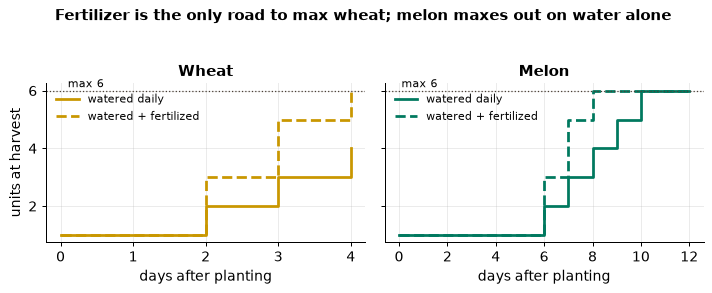

In [7]:
def yield_curve(crop, water=True, fert=False):
    # Day-by-day harvestable units for a one-shot crop (engine WATER logic, per day).
    c, units, curve = CROPS[crop], 1, []
    w0 = (c["max_yield_day"] + 1) // 2
    for age in range(0, c["max_yield_day"] + 1):
        if water and w0 <= age <= c["max_yield_day"]:
            units = min(c["max_yield"], units + (2 if fert else 1))
        curve.append(units)
    return curve

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.1), sharey=True)
for ax, crop in zip(axes, ["WHEAT", "MELON"]):
    c = CROPS[crop]
    for fert, style, lbl in [(False, "-", "watered daily"), (True, "--", "watered + fertilized")]:
        curve = yield_curve(crop, fert=fert)
        ax.step(range(len(curve)), curve, style, where="post", color=CROP_C[crop],
                lw=2.2, label=lbl)
    ax.axhline(c["max_yield"], color="#4A3F35", lw=1, ls=":")
    ax.text(0.1, c["max_yield"] + .12, f"max {c['max_yield']}", fontsize=9)
    ax.set_title(crop.title()); ax.set_xlabel("days after planting")
    ax.legend(fontsize=9, loc="upper left", frameon=False)
axes[0].set_ylabel("units at harvest")
fig.suptitle("Fertilizer is the only road to max wheat; melon maxes out on water alone",
             fontsize=12, weight="bold", y=1.04)
plt.tight_layout(); plt.show()

That asymmetry is worth money: **wheat physically cannot reach its 6-unit cap without fertilizer**
(1 base + 3 watered window days = 4 units max), while melon hits its cap on water alone. Fertilizer costs \$100
at the market — or nothing, because every animal on your farm leaves one collectible fertilizer a
day, fed or hungry (only escaping stops it). The two systems are designed to feed each other.

<a id="s6"></a>
## 6. Animals: wheat-powered factories

An animal is a purchase (goose \$300, cow \$400, sheep \$500) plus a structure — geese need a `COOP`,
cows and sheep a `PASTURE`. Building the structure itself is free; it only costs an action. After
that the contract is simple: **feed it 1 wheat every day** or it escapes after two hungry days
(the building survives, the money does not). In return you get eggs, milk, or wool on a schedule,
plus a free `COLLECT_FERTILIZER` every day.

`CARE` is the part worth reading twice. Every day the animal is both fed and cared for, a counter
goes up by one; on the next production day, **if the animal is fed that day too**, the whole counter
is added to the single unit it would have given you. So a cared animal produces `1 + interval` units
instead of 1: double for a goose, triple for a cow, quadruple for a sheep. The longer the gap
between production days, the more time the counter has to build, so care is worth most on the animal
that pays out least often. Miss the feed on the production day and you lose both the bonus and the
counter, which resets either way. raykkretzschmar wrote up this bonus before I measured it; the
curves below are mine. The slower the animal, the larger the multiplier,
and that is backwards from what the schedule alone suggests.

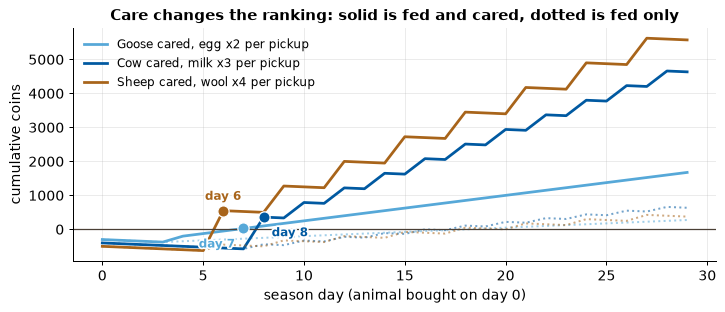

Goose  end of season:   +1,675 cared       +275 fed only
Cow    end of season:   +4,635 cared       +635 fed only
Sheep  end of season:   +5,575 cared       +375 fed only


In [8]:
import matplotlib.patheffects as pe

FEED_COST = BASE["WHEAT"]     # optimistic: base price, the market quotes higher as you buy
season = np.arange(0, 30)          # 720 steps / 24 turns = days 0..29

def payback(a, prod, cared):
    # Mirrors _daily_refresh_animals: a cared+fed day adds 1 to a pending counter, and a production
    # day pays out 1 + whatever has accumulated, capped by max_held.
    cash, pending = [-a["cost"]], 0
    for d in season[1:]:
        units = 0
        if d >= a["first_yield_day"] and (d - a["first_yield_day"]) % a["interval"] == 0:
            units, pending = min(a["max_held"], 1 + pending), 0
        if cared:
            pending += 1
        cash.append(cash[-1] + units * BASE[prod] - FEED_COST)
    return cash

fig, ax = plt.subplots(figsize=(8.2, 3.6))
for animal, a in ANIMALS.items():
    prod = a["product"]
    for cared, style, width, alpha in ((False, ":", 1.6, .55), (True, "-", 2.2, 1.0)):
        cash = payback(a, prod, cared)
        ax.plot(season, cash, style, lw=width, color=PROD_C[prod], alpha=alpha,
                label=(f"{animal.title()} cared, {prod.lower()} x{1 + a['interval']} per pickup"
                       if cared else None))
        be = next((int(d) for d, v in zip(season, cash) if v >= 0), None)
        if be and cared:
            # goose and cow break even a day apart, so separate their labels sideways
            dx, dy, ha = {"GOOSE": (-.4, -560, "right"), "COW": (.4, -560, "left"),
                          "SHEEP": (0, 320, "center")}[animal]
            ax.plot(be, cash[be], "o", ms=9, color=PROD_C[prod], mec="white", zorder=5)
            ax.text(be + dx, cash[be] + dy, f"day {be}", fontsize=9.5, color=PROD_C[prod],
                    weight="bold", ha=ha,
                    path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
ax.axhline(0, color="#4A3F35", lw=1)
ax.set_xlabel("season day (animal bought on day 0)"); ax.set_ylabel("cumulative coins")
ax.set_title("Care changes the ranking: solid is fed and cared, dotted is fed only")
ax.legend(fontsize=9.5, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

for animal, a in ANIMALS.items():
    end_c, end_f = payback(a, a["product"], True)[-1], payback(a, a["product"], False)[-1]
    print(f"{animal.title():6s} end of season: {end_c:+8,.0f} cared   {end_f:+8,.0f} fed only")

Compare each animal's two curves. Fed but never cared for, none of the three earns much over a
season: read the printed line under the chart against what the animal cost you, \$300 for a goose,
\$400 for a cow, \$500 for a sheep. With care the scale changes completely, and the sheep, which is
the slowest and the dearest, ends up in front.

The chart charges full price for feed and gives no credit for the daily fertilizer, so it is the
pessimistic version. What it does not charge for is your time. `CARE` and `FEED` are two visits to
the animal's tile every day, and section 7 is about where those actions come from. The curves also
assume you pick up on every production day: the cap is on what the animal is holding, so an
uncollected cared goose stops earning after two days. Animal
products also pile into the same 100-slot shed as everything else.

<a id="s7"></a>
## 7. Hired hands: the Fibonacci labor market

`HIRE` summons an extra worker at the shed who starts on the next turn and then acts every turn
until nightfall. The n-th hire *of the day* costs `fib(n)` coins: 1, 1, 2, 3, 5, 8, 13... The
counter resets every morning. Do the math on what a coin buys here.

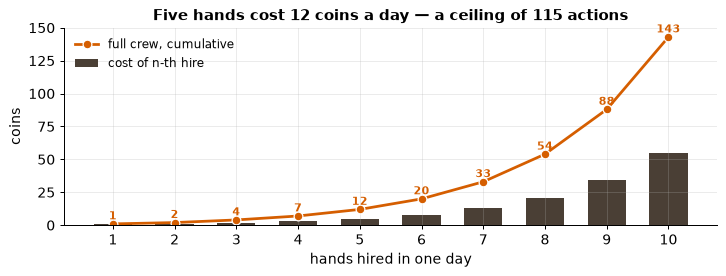

In [9]:
def fib(n):
    a, b = 1, 1
    for _ in range(n):
        a, b = b, a + b
    return a

n_hands = np.arange(1, 11)
costs = [fib(int(n) - 1) for n in n_hands]
cum = np.cumsum(costs)

fig, ax = plt.subplots(figsize=(8.2, 3.2))
bars = ax.bar(n_hands, costs, color="#4A3F35", width=.62, label="cost of n-th hire")
ax.plot(n_hands, cum, "-o", color=P1, lw=2.2, ms=7, mec="white", label="full crew, cumulative")
for x, c in zip(n_hands, cum):
    ax.text(x, c + 3.5, str(int(c)), ha="center", fontsize=9, color=P1, weight="bold")
ax.set_xticks(n_hands)
ax.set_xlabel("hands hired in one day"); ax.set_ylabel("coins")
ax.set_title("Five hands cost 12 coins a day — a ceiling of 115 actions")
ax.legend(fontsize=9.5, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

A hand hired at hour 0 works the remaining 23 turns of the day. Five hands cost **12 coins** and
add up to **115 turns** — a third of one carrot's sale price, for a workforce. Compare that with
anything else in the game: the truly scarce resource here is actions, and hands are how you print
actions. The official starter bot never hires; the most complete public baseline hires seven every
day. That gap is not subtle.

Those 115 turns are a ceiling, and the first day will not give you all of them. A hand appears on
one of the four tiles that touch the shed, one per quadrant, and the engine picks the emptiest of
them without checking whether you own it. On day 0 you own the north-west one and your farmer is
standing on it, so all three hires land on ground you have not bought.

That used to be fatal. Until engine 1.32.3 a unit could not step onto an unbought tile at all, so
the hand that landed south-east was stuck there until nightfall; Victor Mercklé reported it
[in the forum](https://www.kaggle.com/competitions/kaggriculture/discussion/731635) and the fix
shipped a few days later. Units now walk across land they do not own, and the ladder has been
running the fixed engine since the third of August. Check the version printed at the top of this
page against the one you develop on, because that gap is real and it moved twice in a week.

What survives is quieter and it is yours, not the engine's. The hand walks out only if your movement
code lets it, and refusing to step on a locked tile is a natural guard to write. The cell below
plays the same three hires under both policies.

In [10]:
HOME = (4, 4)          # the shed-access tile inside the quadrant you start with

def crowded_hires(batched=True, avoid_locked=False):
    # Hire three hands, then send each one home. avoid_locked = your bot refuses unbought tiles.
    def bot(obs):
        farm, step = obs["farms"][obs["player"]], obs["step"]
        hires = ([["HIRE"]] * 3 if step == 0 else []) if batched else ([["HIRE"]] if step < 3 else [])
        if step == 0:
            return {"farmer": ["PASS"], "hands": [], "market": hires}
        moves = []
        for (x, y) in farm["hands"]:
            if (x, y) == HOME:
                moves.append(["PASS"]); continue
            d = "WEST" if x > HOME[0] else "EAST" if x < HOME[0] else \
                "NORTH" if y > HOME[1] else "SOUTH"
            dx, dy = {"NORTH": (0, -1), "SOUTH": (0, 1), "WEST": (-1, 0), "EAST": (1, 0)}[d]
            if avoid_locked and farm["tiles"][y + dy][x + dx] == "LOCKED":
                d = "PASS"
            moves.append([d])
        return {"farmer": ["PASS"], "hands": moves, "market": hires}

    env = make("kaggriculture", configuration={"seed": 0})
    env.run([bot, "starter"])
    idle = sum(1 for s in env.steps[:24]
               for (x, y) in s[0]["observation"]["farms"][0]["hands"]
               if s[0]["observation"]["farms"][0]["tiles"][y][x] == "LOCKED")
    end = env.steps[23][0]["observation"]["farms"][0]
    stuck = sum(1 for (x, y) in end["hands"] if end["tiles"][y][x] == "LOCKED")
    return idle, stuck

for avoid in (False, True):
    label = "refuses unbought tiles" if avoid else "walks across anything"
    for batched, how in ((True, "hired together"), (False, "hired one per turn")):
        idle, stuck = crowded_hires(batched=batched, avoid_locked=avoid)
        print(f"hands that {label:22s}, {how:18s}: {idle:2d} of 69 worker-turns "
              f"spent on land you do not own, {stuck} still there at nightfall")

hands that walks across anything , hired together    :  4 of 69 worker-turns spent on land you do not own, 0 still there at nightfall
hands that walks across anything , hired one per turn:  3 of 69 worker-turns spent on land you do not own, 0 still there at nightfall
hands that refuses unbought tiles, hired together    : 25 of 69 worker-turns spent on land you do not own, 1 still there at nightfall
hands that refuses unbought tiles, hired one per turn:  3 of 69 worker-turns spent on land you do not own, 0 still there at nightfall


<a id="s8"></a>
## 8. Land: the cheapest scaling in the game

A quadrant is 25 tiles. Whether \$1,000 for NE is "expensive" depends on one number: what a worked
tile earns per day. Take three plain scenarios from section 4 — a lazy \$10/tile-day, a mixed-farm
\$25, an aggressive \$50 — and land pays for itself absurdly fast.

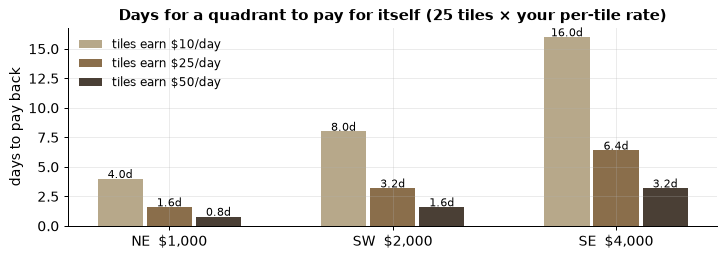

In [11]:
rates = [10, 25, 50]
fig, ax = plt.subplots(figsize=(8.2, 3.0))
width = .22
shade = ["#B7A88A", "#8A6E4B", "#4A3F35"]
for i, rate in enumerate(rates):
    payback = [p / (25 * rate) for p in LAND_PRICES]
    bars = ax.bar(np.arange(3) + (i - 1) * width, payback, width * .92, color=shade[i],
                  label=f"tiles earn ${rate}/day")
    for b, v in zip(bars, payback):
        ax.text(b.get_x() + b.get_width() / 2, v + .06, f"{v:.1f}d", ha="center", fontsize=8.6)
ax.set_xticks(range(3), [f"{q}  ${p:,}" for q, p in zip(LAND_ORDER, LAND_PRICES)])
ax.set_ylabel("days to pay back")
ax.set_title("Days for a quadrant to pay for itself (25 tiles × your per-tile rate)")
ax.legend(fontsize=9.5, frameon=False)
plt.tight_layout(); plt.show()

Even the \$4,000 quadrant pays back in under a week at a modest \$25/tile-day. The real cost of land
is the **labor to work it** (section 7) plus the commute from the shed. That is why land and hands
amount to a single decision.

<a id="s9"></a>
## 9. The market: every sale moves the price against you

Both players sell into **one shared market**. Each product has an inventory; your sales push it up,
purchases and town demand pull it down. Price follows a per-product curve around the resting point
`I0 = 10,000`, and here is the part that decides strategies: **the curve is asymmetric, and it is
different for every product**. The engine's own `market_price()` draws these lines.

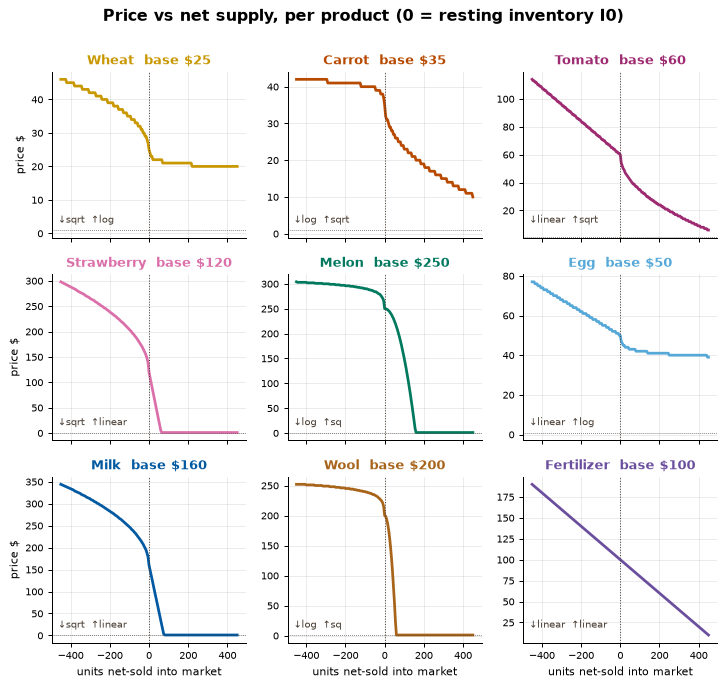

Reality check: melon hits the $1 floor after 158 units net-sold. Wheat after 400 units still sells at $20.


In [12]:
fig, axes = plt.subplots(3, 3, figsize=(8.2, 7.6), sharex=True)
span = np.arange(-450, 451, 5)
for ax, item in zip(axes.flat, PRODUCTS):
    prices = [market_price(item, MARKET_I0 + int(d)) for d in span]
    ax.plot(span, prices, lw=2.2, color=PROD_C[item])
    ax.axvline(0, color="#4A3F35", lw=.8, ls=":")
    ax.axhline(1, color="#4A3F35", lw=.6, ls=":")
    p = MARKET_PARAMS[item]
    ax.set_title(f"{item.title()}  base ${p['base']}", fontsize=10, color=PROD_C[item])
    ax.text(.03, .09, f"↓{p['below_func']}  ↑{p['above_func']}", transform=ax.transAxes,
            fontsize=8.2, color="#4A3F35")
    ax.tick_params(labelsize=8)
for ax in axes[-1]:
    ax.set_xlabel("units net-sold into market", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("price $", fontsize=9)
fig.suptitle("Price vs net supply, per product (0 = resting inventory I0)",
             fontsize=12.5, weight="bold", y=1.0)
plt.tight_layout(); plt.show()

melon_crash = next(d for d in range(1, 1000) if market_price("MELON", MARKET_I0 + d) <= 1)
print(f"Reality check: melon hits the $1 floor after {melon_crash} units net-sold.",
      f"Wheat after 400 units still sells at ${market_price('WHEAT', MARKET_I0 + 400)}.")

The shapes matter as much as the levels. Premium products crash: melon's oversupply curve is
*quadratic* (158 net units and it sits at the \$1 floor); strawberry and milk fall linearly and
hard. Staples shrug: wheat and egg absorb hundreds of units and barely move. So section 4's "melon
wins" bites back — **melon wins only while melons are scarce**, and every player who read the
same table is about to make them plentiful. Two practical corollaries. First, spread your sales
into trickles: both players' orders resolve unit by unit each turn, and the price slides *while*
you sell. Second, scarcity cuts both ways — prices sit *above* base whenever inventory runs short.
One more engine detail: sales at the \$1 floor do not even add to market inventory, so dumping at
the bottom is pure loss.

Here is that curve as a movie: melons piling into the market one at a time. Your shed holds 100, so
a single dump can only reach the dashed line; selling more than that means coming back tomorrow with
the price already pushed down.


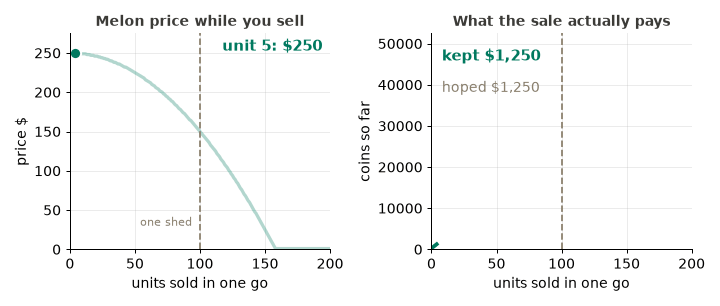

A full shed of 100 melons, sold in one go: $21,721 kept out of the $25,000 the first price promised (87%).
Keep going to 200 and it is $26,527 of $50,000 (53%); melon number 200 sells for $1.


In [13]:
gif, take = dump_gif("MELON", n=200, out="dump.gif")
show_gif(gif)
kept, hoped = take["shed"]
print(f"A full shed of 100 melons, sold in one go: ${kept:,} kept out of the ${hoped:,} the first "
      f"price promised ({kept / hoped:.0%}).")
kept2, hoped2 = take["all"]
print(f"Keep going to 200 and it is ${kept2:,} of ${hoped2:,} ({kept2 / hoped2:.0%}); "
      f"melon number 200 sells for ${take['last']}.")

The dashed line on the right is the daydream: every melon sold at the price the first one fetched.
The solid line is what the engine actually pays, and the two part company almost immediately. One
full shed already costs you more than a tenth of the dream; push on past the vertical marker and
melons start going for a single coin. Spread the same harvest across turns and days, let the town
eat between your sales, and you stay near the top of that curve instead of walking it to the floor.

<a id="s10"></a>
## 10. The town: demand that quadruples by day 20

The town is the pressure-release valve: it consumes products on a schedule, pulling market
inventory down and holding prices up. The **town center** eats 1 of every product except
fertilizer every 12 turns — and its appetite multiplies ×2 from day 10 and ×4 from day 20.
**Shops** unlock every 3 days (one random shop from a pool of 8) and each eats its menu every 4
turns; single-product shops eat double.

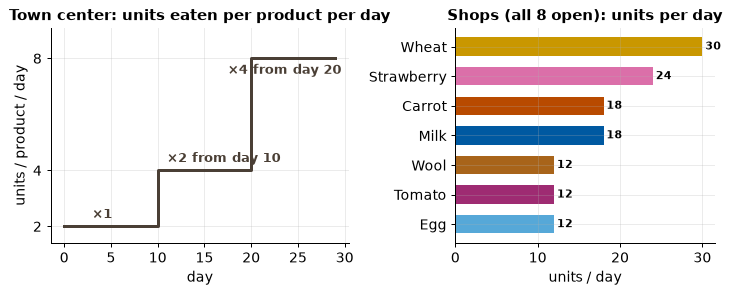

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.4), gridspec_kw={"width_ratios": [1.15, 1]})

days = np.arange(0, 30)
mult = [next(m for th, m in TOWN_CENTER_DEMAND_SCHEDULE if d >= th) for d in days]
center_daily = [2 * m for m in mult]           # 24 turns / 12-turn interval = 2 ticks/day
axes[0].step(days, center_daily, where="post", lw=2.4, color="#4A3F35")
axes[0].set_title("Town center: units eaten per product per day")
axes[0].set_xlabel("day"); axes[0].set_ylabel("units / product / day")
axes[0].set_yticks([2, 4, 8]); axes[0].set_ylim(1.4, 9.1)
for d, v, lbl in [(3, 2.3, "×1"), (11, 4.3, "×2 from day 10"), (17.5, 7.45, "×4 from day 20")]:
    axes[0].text(d, v, lbl, fontsize=10, weight="bold", color="#4A3F35")

daily = {}
for shop, menu in SHOPS.items():
    per_tick = 2 if len(menu) == 1 else 1
    for i in menu:
        daily[i] = daily.get(i, 0) + per_tick * 6    # 24 turns / 4-turn interval
ser = pd.Series(daily).sort_values()
axes[1].barh(ser.index.str.title(), ser.values, color=[PROD_C[i] for i in ser.index], height=.62)
for y, v in enumerate(ser.values):
    axes[1].text(v + .35, y, str(int(v)), va="center", fontsize=9, weight="bold")
axes[1].set_title("Shops (all 8 open): units per day")
axes[1].set_xlabel("units / day")
plt.tight_layout(); plt.show()

Late game, an open Pet Café alone eats **12 carrots a day**, and the ×4 town center clears 8 of
every product it wants daily. Demand ramps exactly when your farm scales — the design is telling
you the endgame is for selling, the early game is for building. Two details are easy to miss. Which
shops open (and in what order) is **random per episode**, so watch `town["unlocked_shops"]`
instead of assuming. And look at what is *missing* from the right panel: **no shop ever buys melon
or fertilizer**, and the town center skips fertilizer too — so fertilizer has no town demand at
all, while melon hangs on the town center alone, which makes its price the most fragile in the
game (section 9 again).

<a id="s11"></a>
## 11. How you actually play: observation and action

Your bot is one function: `agent(obs) -> action`. The observation is a plain dict — here is a real
one, straight from the engine, trimmed to its skeleton.

In [17]:
env = make("kaggriculture", configuration={"seed": 42})
env.run(["starter", "starter"])
obs = env.steps[30][0]["observation"]          # a real observation from early day 1

print(f"day={obs['day']}  hour={obs['hour']}  player={obs['player']}")
me = obs["farms"][0]
print(f"\nfarms[0]:  money=${me['money']:.0f}  farmer={me['farmer']}  "
      f"hands={me['hands']}  unlocked={me['unlocked_quadrants']}  hires_today={me['hires_today']}")
print("tiles[y][x] — one row:", [("~" if t is None else "LOCKED" if t == "LOCKED"
      else t.get("crop", t.get("kind", "?"))) for t in me["tiles"][4][:6]], "...")
plant = next((t for row in me["tiles"] for t in row
              if isinstance(t, dict) and t.get("kind") == "PLANT"), None)
print("a plant tile:", plant)
print("\nprivate:  shed:", {k: v for k, v in obs["private"]["shed"].items() if v},
      " seeds:", {k: v for k, v in obs["private"]["seeds"].items() if v},
      " carrying:", obs["private"]["inventories"])
print("market prices:", obs["market"]["prices"])
print("town:", obs["town"])

day=1  hour=6  player=0

farms[0]:  money=$2960  farmer=[4, 4]  hands=[]  unlocked=['NW']  hires_today=0
tiles[y][x] — one row: ['~', '~', '~', '~', 'CARROT', 'LOCKED'] ...
a plant tile: {'kind': 'PLANT', 'crop': 'CARROT', 'planted_day': 0, 'watered_today': True, 'consecutive_unwatered': 0, 'yield_units': 1, 'max_lifespan_step': 96, 'fertilized_until_day': -1}

private:  shed: {}  seeds: {'CARROT': 1}  carrying: [{}]
market prices: {'WHEAT': 27, 'CARROT': 37, 'TOMATO': 60, 'STRAWBERRY': 135, 'MELON': 262, 'EGG': 50, 'MILK': 175, 'WOOL': 212, 'FERTILIZER': 100}
town: {'unlocked_shops': []}


Three things to notice: your opponent's farm is fully visible in `farms` (money, tiles, workers —
everything except their shed contents, seed counts, and carried inventories, which live in
`private`); the
market and town are shared; and every field is a plain dict, no classes.

The action you return is three lists:

| Key | What it is | Ops |
|---|---|---|
| `farmer` | one op for your farmer | `NORTH SOUTH EAST WEST PASS` · `PLANT crop` · `WATER` · `HARVEST` · `FERTILIZE` · `DIG` · `BUILD_COOP` · `BUILD_PASTURE` · `PLACE item [n]` · `PICKUP item [n]` · `DROP` · `FEED` · `CARE` · `COLLECT_FERTILIZER` |
| `hands` | one op per hired hand, same menu | — |
| `market` | up to 10 orders, resolved in sequence | `["SELL", item, n]` · `["BUY_SEED", crop, n]` · `["BUY_ANIMAL", animal, n]` · `["BUY_PRODUCT", item, n]` (wheat & fertilizer only) · `["HIRE"]` · `["BUY_LAND"]` |

Invalid actions are **silent no-ops** — the engine never errors at you, it just ignores you. Test
locally, because the server will not explain.

<a id="s12"></a>
## 12. A starter bot you can fork

Meet **Carrot Crew**: six carrot tiles around the shed, watered daily, harvested on day 3, walked
home and sold. It is deliberately naive — a lone farmer on its starting quadrant, no animals,
dumping the whole harvest at once — because every one of those gaps is your first improvement
(section 15). What it does have: correct
watering-window timing, weed clearing, and the shed-delivery loop many first bots forget. The cell
writes `main.py`, ready to submit as-is.

In [18]:
%%writefile main.py
# Carrot Crew — a deliberately simple Kaggriculture starter bot.
# Six carrot tiles around the shed spawn, watered daily, sold on harvest.

CARROT = "CARROT"
MAX_YIELD_DAY = 3                                   # CROPS["CARROT"]["max_yield_day"]
PATCH = [(4, 4), (3, 4), (2, 4), (2, 3), (3, 3), (4, 3)]
SHED_TILE = (4, 4)                                  # shed-adjacent: DROP works here


def step_toward(pos, target):
    (x, y), (tx, ty) = pos, target
    if x < tx: return ["EAST"]
    if x > tx: return ["WEST"]
    if y < ty: return ["SOUTH"]
    if y > ty: return ["NORTH"]
    return ["PASS"]


def tile_needs(tile, seeds, day):
    # What this patch tile wants right now, or None.
    if isinstance(tile, dict) and tile.get("kind") == "WEED":
        return ["DIG"]
    if tile is None:
        return ["PLANT", CARROT] if seeds.get(CARROT, 0) > 0 else None
    if isinstance(tile, dict) and tile.get("kind") == "PLANT":
        if not tile.get("watered_today"):
            return ["WATER"]                        # water first — today's bonus lands today
        if day - tile["planted_day"] >= MAX_YIELD_DAY and tile.get("yield_units", 0) > 0:
            return ["HARVEST"]
    return None


def agent(obs):
    me = obs["farms"][obs["player"]]
    private = obs.get("private", {})
    seeds = private.get("seeds", {})
    carrying = (private.get("inventories") or [{}])[0]
    fx, fy = me["farmer"]

    market = []
    in_shed = private.get("shed", {}).get(CARROT, 0)
    if in_shed > 0:
        market.append(["SELL", CARROT, in_shed])    # naive: dump everything (flaw #5, section 15)
    empty = sum(1 for (x, y) in PATCH if me["tiles"][y][x] is None)
    need = empty - seeds.get(CARROT, 0)
    if need > 0 and me["money"] >= 20 * need:
        market.append(["BUY_SEED", CARROT, need])

    # Priorities, in order: tend the living, deliver the harvest, then plant.
    # Watering and harvesting outrank replanting because a seed can wait an
    # hour, while a crop past its window decays into a weed — flip the order
    # and watch the far row die before the farmer reaches it.

    # 1. Living plants and weeds: the tile underfoot first, then walk to one.
    here = me["tiles"][fy][fx]
    if (fx, fy) in PATCH and here is not None:
        act = tile_needs(here, seeds, obs["day"])
        if act:
            return {"farmer": act, "hands": [], "market": market}
    for (x, y) in PATCH:
        tile = me["tiles"][y][x]
        if (x, y) != (fx, fy) and tile is not None and tile_needs(tile, seeds, obs["day"]):
            return {"farmer": step_toward((fx, fy), (x, y)), "hands": [], "market": market}

    # 2. Full basket (a whole row's worth): walk home and drop it so it can sell.
    if carrying.get(CARROT, 0) >= 9:
        if (fx, fy) == SHED_TILE:
            return {"farmer": ["DROP"], "hands": [], "market": market}
        return {"farmer": step_toward((fx, fy), SHED_TILE), "hands": [], "market": market}

    # 3. Planting: the tile underfoot first, then walk to an empty one.
    if (fx, fy) in PATCH and here is None and seeds.get(CARROT, 0) > 0:
        return {"farmer": ["PLANT", CARROT], "hands": [], "market": market}
    for (x, y) in PATCH:
        if (x, y) != (fx, fy) and me["tiles"][y][x] is None and seeds.get(CARROT, 0) > 0:
            return {"farmer": step_toward((fx, fy), (x, y)), "hands": [], "market": market}

    # 4. Nothing else to do: deliver whatever we hold.
    if carrying.get(CARROT, 0) > 0:
        if (fx, fy) == SHED_TILE:
            return {"farmer": ["DROP"], "hands": [], "market": market}
        return {"farmer": step_toward((fx, fy), SHED_TILE), "hands": [], "market": market}
    return {"farmer": ["PASS"], "hands": [], "market": market}

Writing main.py


<a id="s13"></a>
## 13. Watch a full game

Carrot Crew (blue) vs the built-in `starter` bot (a single-tile carrot loop, orange), full 720
turns, fixed seed so the numbers reproduce.

Final banks — Carrot Crew: $7,381   built-in starter: $3,384


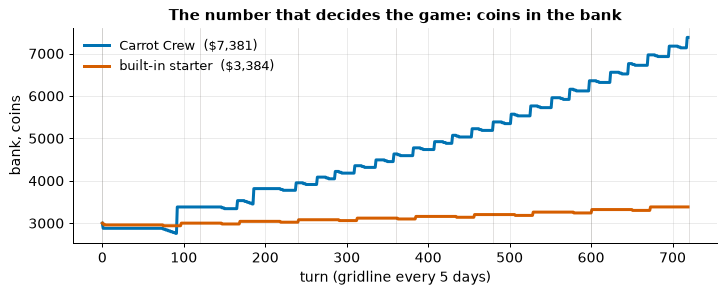

In [19]:
env = make("kaggriculture", configuration={"seed": 42}, debug=True)
env.run(["main.py", "starter"])

money = {i: [step[0]["observation"]["farms"][i]["money"] for step in env.steps] for i in (0, 1)}
final = {i: env.steps[-1][i]["reward"] for i in (0, 1)}
print(f"Final banks — Carrot Crew: ${final[0]:,.0f}   built-in starter: ${final[1]:,.0f}")

fig, ax = plt.subplots(figsize=(8.2, 3.4))
turns = np.arange(len(money[0]))
ax.plot(turns, money[0], color=P0, lw=2.4, label=f"Carrot Crew  (${final[0]:,.0f})")
ax.plot(turns, money[1], color=P1, lw=2.4, label=f"built-in starter  (${final[1]:,.0f})")
for d in range(0, 31, 5):
    ax.axvline(d * 24, color="#4A3F35", lw=.5, alpha=.25)
ax.set_xlabel("turn (gridline every 5 days)"); ax.set_ylabel("bank, coins")
ax.set_title("The number that decides the game: coins in the bank")
ax.legend(fontsize=10, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()


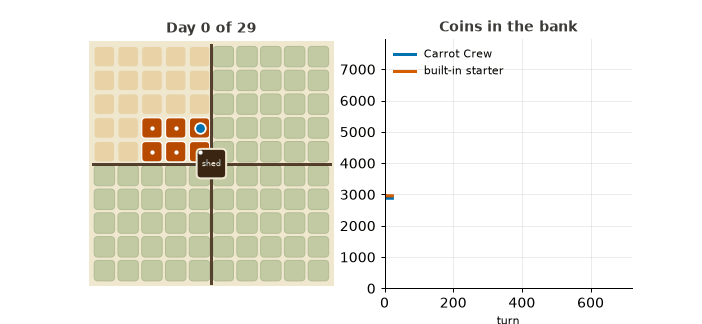

In [21]:
show_gif(season_gif(env.steps, out="season.gif"))

Thirty days in eight seconds. Warm tiles are ground you own and work, green is wild land you never
bought, a dot on a crop means it is ready to harvest, and the blue marker is your farmer walking
his six-tile loop. Six tiles beat one tile by a wide margin, so scale wins even at this toy level.

Now watch what the *winning* farm never does: it never crosses into the green, never builds a coop,
never hires a second pair of hands, and dumps its whole basket into the market the moment it gets
home.

<a id="s14"></a>
## 14. Measure it before you optimize it

That was one game, on one seed, against one opponent, and one game tells you very little here.
Section 10 is the reason: the town unlocks a random shop every three days, so two episodes hand
your bot different demand entirely.

Two properties of this environment decide how you should test anything, and the cell below runs
both against your own bot rather than asking you to believe mine. A seed replays exactly, as long
as your bot is deterministic: no unseeded `random`, no clock, no iteration over a set. And on every
seed I have checked, the seat does not move Carrot Crew's bank, which fits how the market reads:
it clears unit by unit and quotes both players against the same pre-commit inventory before either
one commits.

Both save you runs. A repeat of one seed hands back the same game, not a second sample. And you can
play one seat instead of two. The weed draw genuinely is seat dependent, so that exemption is not
free: it holds for Carrot Crew only because Carrot Crew works six fixed tiles and never weeds. Let
the check speak for your bot before you halve anything.

In [25]:
MY_AGENT = "main.py"          # TWEAK THIS: every cell in this section reads this one name

def play(agent_file, seed, opponent="starter", seat=0):
    env = make("kaggriculture", configuration={"seed": int(seed)})
    env.run([agent_file, opponent] if seat == 0 else [opponent, agent_file])
    banks = [s["reward"] for s in env.steps[-1]]
    return banks[seat], banks[1 - seat]                    # mine, theirs

here = play(MY_AGENT, 0)[0]
spoken = subprocess.run(             # a fresh interpreter, so set order and hash seeds differ too
    [sys.executable, "-c", "from kaggle_environments import make; "
     f"e = make('kaggriculture', configuration={{'seed': 0}}); e.run(['{MY_AGENT}', 'starter']); "
     "print(e.steps[-1][0]['reward'])"], capture_output=True, text=True).stdout.split()
elsewhere = float(spoken[-1]) if spoken else math.nan      # the engine logs first, the bank last

if math.isnan(elsewhere):
    verdict = "the fresh process gave no answer, so skip this one"
elif elsewhere == here:
    verdict = "identical, so a repeat is the same game again"
else:
    verdict = "DIFFERENT, so your bot carries randomness of its own and repeats do help"
print(f"seed 0 here and in a fresh process: {here:>9,.0f} and {elsewhere:>9,.0f}  ->  {verdict}")

seats = [(s, play(MY_AGENT, s)[0], play(MY_AGENT, s, seat=1)[0]) for s in (0, 1, 2)]
print("seeds 0-2, seat 0 against seat 1: "
      + ", ".join(f"{a:,.0f} vs {b:,.0f}" for _, a, b in seats) + "  ->  "
      + ("same both ways, so one seat is enough" if all(a == b for _, a, b in seats)
         else "DIFFERENT, so keep playing both seats"))

seed 0 here and in a fresh process:     7,947 and     7,947  ->  identical, so a repeat is the same game again
seeds 0-2, seat 0 against seat 1: 7,947 vs 7,947, 8,313 vs 8,313, 8,337 vs 8,337  ->  same both ways, so one seat is enough


What is left is that seeds differ from each other far more than most real improvements do. The cell
below is the way around that: play every seed with *both* versions of your bot, and read the
difference seed by seed instead of comparing two averages.

One word you need for the output. The **standard error** is how far that average difference would
jump around if you re-ran the whole test on a different list of seeds. The working rule: keep the
change if the average is more than two standard errors from zero, and if most seeds lean the same
way.

In [23]:
SEEDS = range(12)             # four times the seeds halves the band; twelve is about a minute

def compare(version_a, version_b, seeds=SEEDS):
    # Every seed is played by BOTH versions, so whatever luck that seed carries cancels out.
    rows = []
    for s in seeds:
        a, starter = play(version_a, s)
        b, _ = play(version_b, s)
        rows.append({"seed": int(s), "a": a, "b": b, "starter": starter})
    df = pd.DataFrame(rows)
    return df.assign(diff=df.a - df.b)

That is the instrument. Below is a throwaway second version to point it at: Carrot Crew with one
constant moved. Replace both filenames with your own two versions once you have a change to test.

In [24]:
from pathlib import Path

OLD, NEW = "CARROT, 0) >= 9:", "CARROT, 0) >= 6:"     # v2 delivers at 6 carrots instead of 9
src = Path(MY_AGENT).read_text()
assert OLD in src, f"{MY_AGENT} has no {OLD!r}. Point OLD at a constant your own file contains."
Path("main_v2.py").write_text(src.replace(OLD, NEW))

VERSION_A, VERSION_B = MY_AGENT, "main_v2.py"         # TWEAK THIS: your own two versions
pairs = compare(VERSION_A, VERSION_B)                 # two games per seed; slow bots, slow cell

n_seeds, mean_diff = len(pairs), pairs["diff"].mean()
paired_se = pairs["diff"].std() / n_seeds ** .5                  # one shared seed list
lone_se = (pairs.a.var() + pairs.b.var()) ** .5 / n_seeds ** .5  # a fresh list for each version

print(f"Sanity first: A beat the built-in starter on {(pairs.a > pairs.starter).sum()} of {n_seeds}"
      f" seeds, by {(pairs.a - pairs.starter).mean():+,.0f} coins on average.")
print(f"A minus B: {mean_diff:+,.1f} coins per seed, "
      f"A ahead on {(pairs['diff'] > 0).sum()} of {n_seeds} seeds.")
if paired_se == 0:
    print("  the two versions scored identically on every seed: is B really a different file?")
else:
    print(f"  one shared seed list  -> standard error {paired_se:7.2f}")
    print(f"  fresh seeds for each  -> standard error {lone_se:7.2f}"
          f"   ({lone_se / paired_se:.1f}x wider)")
    print("  verdict: " + ("clears two standard errors on shared seeds"
                           if abs(mean_diff) > 2 * paired_se else "inside the noise even paired"))
    print("           " + ("and would survive fresh seeds too" if abs(mean_diff) > 2 * lone_se
                           else "and on fresh seeds it would vanish"))
print(f"  (scoring the lead instead: spread {pairs.a.std():,.0f} -> "
      f"{(pairs.a - pairs.starter).std():,.0f} coins, because the starter's own bank "
      f"only moves {pairs.starter.std():,.0f})")

Sanity first: A beat the built-in starter on 12 of 12 seeds, by +4,486 coins on average.
A minus B: +18.9 coins per seed, A ahead on 12 of 12 seeds.
  one shared seed list  -> standard error    3.66
  fresh seeds for each  -> standard error  156.48   (42.8x wider)
  verdict: clears two standard errors on shared seeds
           and on fresh seeds it would vanish
  (scoring the lead instead: spread 378 -> 330 coins, because the starter's own bank only moves 48)


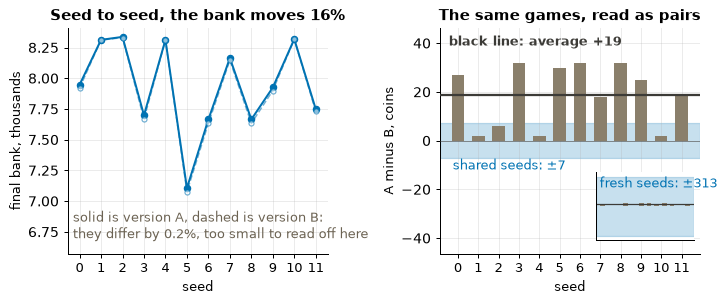

Median turn: 0.008 ms against a 1 s actTimeout plus 60 s of overage. Wall clock, so unlike the banks above this one moves between runs.


In [26]:
import statistics, time, importlib
sys.path.insert(0, ".")
my_bot = importlib.import_module(MY_AGENT.removesuffix(".py"))   # written in section 12
importlib.reload(my_bot)

turn_ms = []                                     # one extra game, played only to time the turn
def timed_agent(obs):
    t0 = time.perf_counter()
    action = my_bot.agent(obs)
    turn_ms.append((time.perf_counter() - t0) * 1000)
    return action

env = make("kaggriculture", configuration={"seed": 42})
env.run([timed_agent, "starter"])
median_ms = statistics.median(turn_ms)
budget_s = env.configuration.actTimeout
overage_s = env.steps[0][0]["observation"]["remainingOverageTime"]

fig, (axS, axP) = plt.subplots(1, 2, figsize=(8.2, 3.5))
x = np.arange(n_seeds)

axS.plot(x, pairs.a / 1000, "o-", color=P0, ms=5, lw=1.6)
axS.plot(x, pairs.b / 1000, "o--", color=P0, ms=4, lw=1.2, alpha=.55, mfc="white")
lo = min(pairs.a.min(), pairs.b.min()) / 1000
hi = max(pairs.a.max(), pairs.b.max()) / 1000
axS.set_ylim(lo - (hi - lo) * .40, hi + (hi - lo) * .06)     # room under the curves for the note
axS.text(.02, .05, f"solid is version A, dashed is version B:\n"
         f"they differ by {abs(mean_diff) / pairs.a.mean():.1%}, too small to read off here",
         transform=axS.transAxes, ha="left", va="bottom", fontsize=10, color="#6C6353")
axS.set_xticks(x, pairs.seed.astype(str), fontsize=10)
axS.set_xlabel("seed", fontsize=10); axS.set_ylabel("final bank, thousands", fontsize=10)
axS.set_title(f"Seed to seed, the bank moves "
              f"{(pairs.a.max() - pairs.a.min()) / pairs.a.mean():.0%}")

span = max(pairs["diff"].abs().max(), 2 * paired_se, abs(mean_diff)) * 1.45
axP.axhspan(-2 * paired_se, 2 * paired_se, color=P0, alpha=.22, ec=P0, lw=1)
axP.bar(x, pairs["diff"], color="#8A7F6B", width=.62, zorder=3)
axP.axhline(mean_diff, color=INK, lw=1.8, zorder=5)
axP.axhline(0, color=INK, lw=.8, alpha=.5, zorder=4)
axP.text(-.45, -2 * paired_se, f" shared seeds: ±{2*paired_se:.0f}",
         ha="left", va="top", fontsize=10, color=P0)
axP.text(-.45, span * .93, f"black line: average {mean_diff:+,.0f}", ha="left", va="top",
         fontsize=10, color=INK, weight="bold")          # kept off the bars, wherever they land
axP.set_ylim(-span, span)
axP.set_xticks(x, pairs.seed.astype(str), fontsize=10)
axP.set_xlabel("seed", fontsize=10); axP.set_ylabel("A minus B, coins", fontsize=10)
axP.set_title("The same games, read as pairs")

ins = axP.inset_axes([.60, .06, .38, .30])                  # the same bars at fresh-seed scale
ins.axhspan(-2 * lone_se, 2 * lone_se, color=P0, alpha=.22)      # the same band, same colour
ins.bar(x, pairs["diff"], color="#8A7F6B", width=.62)
ins.axhline(mean_diff, color=INK, lw=1)                          # the average, landing on zero
ins.set_ylim(-2.3 * lone_se, 2.3 * lone_se)
ins.set_xticks([]); ins.set_yticks([])
ins.text(.04, .94, f"fresh seeds: ±{2*lone_se:.0f}", transform=ins.transAxes, va="top",
         fontsize=10, color=P0)

plt.tight_layout(); plt.show()
print(f"Median turn: {median_ms:.3f} ms against a {budget_s:.0f} s actTimeout plus {overage_s:.0f} s"
      f" of overage. Wall clock, so unlike the banks above this one moves between runs.")

In the left panel one constant changed, the opponent never did, and the bank still walks up and
down with the seed. A tweak that wins one seed and loses the next has taught you nothing yet.

The right panel is those same games read as pairs, one bar per seed. The bars are small and they
all lean the same way, and the black average line sits clear of the blue band, which is the range a
test on one shared seed list cannot separate from zero. The inset is the same twelve bars drawn at
the scale a fresh list for each version would work at: the bars disappear and the average with
them.

Subtracting the starter's bank rather than pairing your own versions shaves off only part of the
seed, as the line under the A-minus-B numbers shows, because that bank barely moves in the first
place. And repeating a seed hands back the same game, because the replay is exact.

That win is a best case, though. Carrot Crew works six fixed tiles and mostly ignores the board, so
its two versions take almost the same path through a game and share almost all of the luck a seed
hands out. A bot that reacts to prices will have its two versions diverge, so they share less and
pairing buys less than it does here.

Turn time will not be your constraint. Carrot Crew thinks for a few thousandths of a millisecond
against a one-second `actTimeout`, with a minute of overage behind it. Whatever your next idea
costs, whether that is scoring every tile or looking a few days ahead, you have the budget for it.

The environment also ships a player, if you would rather watch a game than read its numbers:

```python
env.render(mode="ipython", width=800, height=600)
```

I keep it out of this notebook on purpose: the player bundles about 20 MB of replay into the page,
which is several times the weight of this entire page, animations and all.

<a id="s15"></a>
## 15. From the starter bot to a real strategy

Before the improvement list, a yardstick. Every finished ladder game leaves a public replay, and I
collect what the API serves into the [Kaggriculture Episodes](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes)
dataset. It is attached to this notebook, so the two panels below recompute from ladder games every
time this page runs.

In [ ]:
episodes, agents = load_table("episodes"), load_table("agents")

ladder = episodes[episodes["type"] == "EPISODE_TYPE_PUBLIC"]          # ladder games, not self-play
runs = (agents[agents.episode_id.isin(ladder.episode_id)]
        .merge(ladder[["episode_id", "end_time"]], on="episode_id"))
runs["end_time"] = pd.to_datetime(runs["end_time"])
assert len(runs) > 20, f"only {len(runs)} ladder results found; the data looks wrong"

MINE, THEIRS = final[0], final[1]                                     # the single game in section 13
pct = lambda v: (runs.final_bank < v).mean() * 100

fig, (axH, axS) = plt.subplots(1, 2, figsize=(8.2, 3.4))

axH.hist(runs.final_bank / 1000, bins=40, color="#8A7F6B")
for i, (bank, color, label) in enumerate([(THEIRS, P1, "built-in starter"), (MINE, P0, "Carrot Crew")]):
    axH.axvline(bank / 1000, color=color, lw=2.2)
    axH.text(.33, .95 - i * .23, f"{label} {bank/1000:.1f}k\n{pct(bank):.0f}% of results are lower",
             transform=axH.transAxes, fontsize=9, color=color, weight="bold", va="top")
axH.text(.33, .49, "both scored in our local duel,\nnot on the ladder", transform=axH.transAxes,
         fontsize=9, color="#4A3F35", va="top")
axH.set_title(f"Where a farm lands: {len(runs):,} ladder results")
axH.set_xlabel(f"final bank, thousands of coins   (games up to {runs.end_time.max():%d %b})")
axH.set_ylabel("results")

teams = pd.DataFrame({
    "rating": runs.sort_values("end_time").groupby("team_id").rating_after.last(),
    "bank": runs.groupby("team_id").final_bank.median(),
})
rho = teams.bank.corr(teams.rating, method="spearman")
axS.scatter(teams.bank / 1000, teams.rating, s=48, color="#00795F", alpha=.75,
            edgecolor="white", linewidth=1.2)
axS.set_title(f"Median bank vs rating: {len(teams)} teams, rho {rho:.2f}")
axS.set_xlabel("team's median bank, thousands"); axS.set_ylabel("rating after its latest game here")

plt.tight_layout(); plt.show()

print(f"Ladder median bank: {runs.final_bank.median():,.0f} coins, "
      f"across {teams.shape[0]} teams.")

Two things a beginner should take from this. **Your first bot is not broken.** Carrot Crew scores
in the lower part of the ladder distribution, which is where a six-tile farm belongs. The gap to
the top is scale. Read that comparison carefully, though: my two numbers come from a local duel
against the built-in bot, the histogram from ladder games between submitted agents. Same units,
different opponents.

**And coins really are the currency of winning.** Teams with fatter median banks sit higher on the
rating axis. The engine hands the win to whoever ends the season richer, and only outcomes move
rating, so the pattern is what you would expect — the scatter shows it holding across the field,
not why any single bot is good.

That right tail of the histogram is worth seeing rather than reading about. Here is the biggest
farm in the dataset, replayed next to ours, day for day.

Their farm ended on 4 of 4 quadrants with 20 animals; ours on 1 quadrant with none.



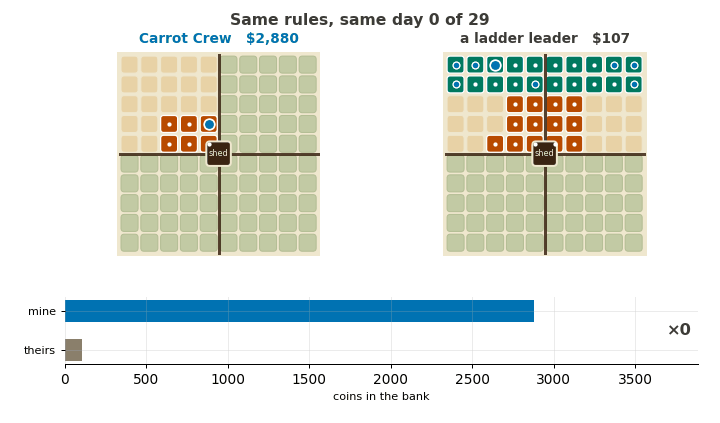

In [ ]:
show_gif(versus_gif(env.steps, out="versus.gif"))

Same thirty days, same rules, same starting \$3,000. The difference is not a trick or a secret
formula: the leader buys land it can work, fills it with assets that pay every single day, and
keeps compounding to the last turn, while Carrot Crew tends its six tiles and stops. That gap is
the whole reason the improvement list below is worth working through.

Curious how that farm is built, measurably? I keep a companion notebook,
[Kaggriculture Daily Replays: The Live Meta Report](https://www.kaggle.com/code/georgymamarin/kaggriculture-daily-replays-the-live-meta-report),
that opens the same dataset's replays and asks what the biggest farms do differently: how their
banks compound through the season, how deep their hired crews go, when they buy land, and how the
market bends around the way they buy and sell. This guide teaches the rules; that one watches the
field play by them.

Now the improvement queue — each flaw in Carrot Crew is a strategy lesson in disguise, in
rough order of payoff:

1. **It never hires, and bolting hands on does not fix it.** Twelve coins buy five hands and a
   ceiling of 115 turns (section 7), which looks like the obvious first improvement. I tried it two
   ways, both offline rather than in a cell here, both against the built-in starter. Hands that
   mostly idle cost exactly the hire fee and nothing more: minus four coins on all ten seeds. Hands
   wired to run the same job list as the farmer worked hard, 44 plantings in one day, and did worse,
   minus 58 on seed 0. I have not pinned down where that goes; the honest summary is that a job list
   written for one worker does not become better by being handed to four. Extra hands are extra
   actions, not extra judgement, and this bot's problem is judgement.
2. **It farms one crop.** Section 4's table is a menu, not a verdict — melon's paper profit meets
   melon's quadratic crash curve (section 9). A portfolio sells into five gentle price curves
   instead of one cliff.
3. **It ignores animals.** Every animal is a compounding asset that also prints free fertilizer —
   and fertilizer is the only road to max wheat (section 5).
4. **It never buys land.** A quadrant pays for itself in days (section 8) — *if* you have the
   labor, which is point 1 again.
5. **It dumps its harvest.** Orders resolve unit by unit, so a bulk dump slides the price as it
   fills (section 9). Trickle sales across turns, and watch the town's demand schedule
   (section 10) — the same goods are worth more after day 20.

One caveat: beating the built-in `starter` says your plumbing works, nothing more. The
ladder pairs you against real bots via skill rating, and only the outcome — win, loss, or tie —
moves it; margin of victory does not.

<a id="s16"></a>
## 16. Cheat sheet

Everything above, in two tables generated straight from the engine's constants — screenshot these.

In [24]:
crop_rows = []
for crop, c in CROPS.items():
    crop_rows.append({
        "crop": crop.title(), "seed $": c["seed"], "base $": BASE[crop],
        "type": "ongoing" if c["ongoing"] else "one-shot",
        "first harvest, day": c["first_yield_day"],
        "schedule": (f"fruit every {c['interval']}d × {c['max_yield']}" if c["ongoing"]
                     else f"done on day {one_shot_days(crop)}, up to {one_shot_units(crop)}u watered"),
    })
animal_rows = []
for animal, a in ANIMALS.items():
    animal_rows.append({
        "animal": animal.title(), "cost $": a["cost"], "home": a["structure"].lower(),
        "product": a["product"].title(), "base $": BASE[a["product"]],
        "first product, day": a["first_yield_day"], "then every": f"{a['interval']}d",
        "holds": a["max_held"],
    })
sty = [{"selector": "th", "props": [("font-size", "13px")]}]
display(pd.DataFrame(crop_rows).style.hide(axis="index").set_properties(**{"font-size": "13px"})
        .set_table_styles(sty))
display(pd.DataFrame(animal_rows).style.hide(axis="index").set_properties(**{"font-size": "13px"})
        .set_table_styles(sty))

crop,seed $,base $,type,"first harvest, day",schedule
Wheat,10,25,one-shot,2,"done on day 4, up to 4u watered"
Carrot,20,35,one-shot,2,"done on day 3, up to 3u watered"
Tomato,50,60,ongoing,8,fruit every 1d × 4
Strawberry,100,120,ongoing,10,fruit every 2d × 4
Melon,80,250,one-shot,10,"done on day 10, up to 6u watered"


animal,cost $,home,product,base $,"first product, day",then every,holds
Goose,300,coop,Egg,50,4,1d,4
Cow,400,pasture,Milk,160,8,2d,6
Sheep,500,pasture,Wool,200,6,3d,6


And the rules that cost people games:

- **The watering counter kills at 2.** Planting day already counts as dry day one — water the
  plant the day it goes in, and never skip two days in a row afterwards. Two hungry days in a row
  make an animal escape.
- **Shed cap 100** — end-of-day overflow is destroyed. Seeds have their own uncapped slot.
- **10 market orders max per turn**; invalid actions are silent no-ops.
- **Hands vanish at nightfall**; the n-th hire of a day costs `fib(n)`, and the counter resets
  every morning.
- **Land order is fixed**: NE \$1,000 → SW \$2,000 → SE \$4,000.
- **Sales at the \$1 floor add nothing to market inventory** — a dump at the bottom is pure loss.
- **`BUY_PRODUCT` covers wheat and fertilizer only.**
- **1 second per turn** (60-second total overage budget) — a timeout ends your episode.

<a id="s17"></a>
## 17. Submit your agent

Three ways to get `main.py` onto the ladder:

1. **The Submit button** on the [competition page](https://www.kaggle.com/competitions/kaggriculture)
   — upload `main.py` directly.
2. **The CLI**: `kaggle competitions submit kaggriculture -f main.py -m "Carrot Crew v1"` (bundle
   multi-file bots as `submission.tar.gz` with `main.py` at the root).
3. **From a notebook** like this one: run it, then submit the produced `main.py`.

What happens next: a **validation episode** runs your bot against a copy of itself — if it crashes,
the submission shows `Error` and you can download the logs. Then it enters matchmaking with a
provisional rating. You get **5 submissions a day**, and only your **latest 2** are tracked for
matchmaking and the final leaderboard — so a submission is not a save slot; it is a lineup
decision.
Mind the clock: **1 second per turn**, and heavy imports eat into a 60-second overage budget.

<a id="s18"></a>
## 18. Further reading & credits

The competition is young and the shelf is still short — I keep this section updated as the field
grows (that is a promise — check back):

**Start here**
- [Kaggriculture: Getting Started](https://www.kaggle.com/code/bovard/kaggriculture-getting-started)
  by Bovard Doerschuk-Tiberi (Kaggle) — the official walkthrough: mechanics from the horse's mouth
  and a melon-focused example bot.
- [How to get started + Official Discord](https://www.kaggle.com/competitions/kaggriculture/discussion/730708)
  by María Cruz (Kaggle) — team-up thread and the community Discord.

**Stronger baselines to study**
- [Diversified Scheduler Baseline](https://www.kaggle.com/code/ektarr/diversified-scheduler-baseline-kaggriculture)
  by Maxim — the most complete public bot so far: seven hands a day, a per-unit task scheduler, and
  a mixed-crop portfolio. Read it after section 15 and you will recognize every idea.
- [Start_with_Basic_Simple](https://www.kaggle.com/code/dheerajkannaujiya/start-with-basic-simple)
  by Ᏸ𐍂Ꭷ — a compact single-crop bot with Manhattan pathfinding.

**The source of truth**
- [kaggle-environments — kaggriculture engine](https://github.com/Kaggle/kaggle-environments/tree/master/kaggle_environments/envs/kaggriculture)
  — every constant in this guide lives in `kaggriculture.py`. When in doubt, read the interpreter;
  it is 1,000 lines and honest.

**What the ladder is doing**
- [Kaggriculture Daily Replays: The Live Meta Report](https://www.kaggle.com/code/georgymamarin/kaggriculture-daily-replays-the-live-meta-report)
  — my companion notebook: what the farms at the top of the ladder do differently, read off their
  replays. Worth a look once the mechanics here feel familiar.
- [Kaggriculture Episodes](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes)
  — the dataset behind both notebooks: ladder results plus full replays, refreshed on a schedule.
  Section 15's two panels read its tables, so you can check those claims against real games.

Credits: the Kaggle team for an environment where the economics are the game, and the authors above
for the first public baselines. This is the second guide in my "…, Visualized" series — the first,
[Orbit Wars, Visualized](https://www.kaggle.com/code/georgymamarin/orbit-wars-visualized-a-beginners-guide),
covers the previous competition in the genre.

**Fork it, fix flaw #1, and submit — then tell me in the comments what your first improvement
bought you. If this guide saved you an evening, an upvote keeps it visible for the next newcomer.**

*— [Georgy Mamarin](https://www.kaggle.com/georgymamarin)*